# Day 05: KV Cache — The Most Important Optimization in Inference

> *100 Days of Inference* | Based on *Inference Engineering* Ch 5.3 (Philip Kiely)

**Layer:** Runtime  
**Prerequisite:** Day 02 (GPT-2 weights, attention from scratch)  
**Time:** ~30 minutes

---

By the end of this notebook you will have:
- Measured the quadratic cost of naive autoregressive generation
- Built a `KVCache` class that stores K and V tensors across decode steps
- Implemented a GPT-2 forward pass that uses the cache
- Benchmarked the speedup across sequence lengths 10 → 500
- Computed KV cache memory cost for models from GPT-2 to GPT-3 scale

## The Problem: O(n²) Attention

In Day 01 you saw this loop:

```
step 1: forward_pass([token_0])                          → token_1
step 2: forward_pass([token_0, token_1])                 → token_2
step 3: forward_pass([token_0, token_1, token_2])        → token_3
...
step N: forward_pass([token_0, token_1, ..., token_N-1]) → token_N
```

Each step re-processes the **entire sequence from scratch**. At step N, the model runs attention over N tokens.
Total attention work across all steps: `1 + 2 + 3 + ... + N = N(N+1)/2 = O(N²)`.

This is like a log aggregation system that re-reads all historical logs from disk every time a new log line arrives, just to count the total — instead of keeping a running counter.

**Why does attention re-read past tokens?**

Attention works by computing three matrices from the input: **Q** (query), **K** (key), **V** (value).
For each token, it asks: "which past tokens are relevant to me?" It does this by:
1. Computing a similarity score between the current token's Q and every past token's K
2. Using those scores to weight-sum the V vectors

```
Input tokens: [t0, t1, t2, t3]  (4 tokens)

K = [K0, K1, K2, K3]   <- "what each token is willing to match"
V = [V0, V1, V2, V3]   <- "what each token contributes if matched"
Q = [Q0, Q1, Q2, Q3]   <- "what each token is looking for"

For t3 (the new token):
  scores = Q3 @ [K0, K1, K2, K3]^T  = [s0, s1, s2, s3]
  output = softmax(scores) @ [V0, V1, V2, V3]
```

**The key insight:** K0, K1, K2 and V0, V1, V2 are computed from past tokens. Those tokens haven't changed. Their K and V are **identical** in step N as they were in step N-1. Yet without a cache, we recompute them from scratch every step.

**Infra analogy:** This is a DNS resolver that re-queries authoritative nameservers for `google.com` on every request, instead of caching the response with its TTL. The KV cache is the DNS cache — same data, don't recompute it.

In [9]:
# Setup: imports, load GPT-2 weights
import json
import struct
import os
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# --- Download weights if needed ---
MODEL_DIR = "../day02/gpt2_weights"
if not os.path.exists(os.path.join(MODEL_DIR, "model.safetensors")):
    MODEL_DIR = "gpt2_weights"
    os.makedirs(MODEL_DIR, exist_ok=True)
    BASE_URL = "https://huggingface.co/openai-community/gpt2/resolve/main"
    for fname in ["model.safetensors", "config.json", "vocab.json", "merges.txt"]:
        path = os.path.join(MODEL_DIR, fname)
        if not os.path.exists(path):
            print(f"Downloading {fname}...", end=" ", flush=True)
            urllib.request.urlretrieve(f"{BASE_URL}/{fname}", path)
            print("done")
        else:
            print(f"  {fname}: already exists")

print(f"Loading weights from: {MODEL_DIR}/")

# --- Parse SafeTensors ---
def parse_safetensors(path):
    with open(path, "rb") as f:
        header_len = struct.unpack("<Q", f.read(8))[0]
        header = json.loads(f.read(header_len))
        data_start = 8 + header_len
        tensors = {}
        for name, info in header.items():
            if name == "__metadata__":
                continue
            dtype = {"F32": np.float32, "F16": np.float16}[info["dtype"]]
            start, end = info["data_offsets"]
            f.seek(data_start + start)
            tensors[name] = np.frombuffer(f.read(end - start), dtype=dtype).reshape(info["shape"])
        return tensors

weights = parse_safetensors(os.path.join(MODEL_DIR, "model.safetensors"))

# --- Load config ---
with open(os.path.join(MODEL_DIR, "config.json")) as f:
    config = json.load(f)

N_LAYER = config["n_layer"]    # 12
N_EMBD  = config["n_embd"]     # 768
N_HEAD  = config["n_head"]     # 12
HEAD_DIM = N_EMBD // N_HEAD    # 64
VOCAB_SIZE = config["vocab_size"]  # 50257

print(f"GPT-2: {N_LAYER} layers, {N_EMBD}d, {N_HEAD} heads, head_dim={HEAD_DIM}")
print(f"Vocab: {VOCAB_SIZE} tokens")

# --- Minimal tokenizer (from day02b) ---
with open(os.path.join(MODEL_DIR, "vocab.json")) as f:
    vocab = json.load(f)
with open(os.path.join(MODEL_DIR, "merges.txt")) as f:
    merges_raw = f.read().strip().split("\n")[1:]

id_to_token = {v: k for k, v in vocab.items()}
bpe_ranks = {tuple(m.split()): i for i, m in enumerate(merges_raw)}

def bytes_to_unicode():
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = list(bs)
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return dict(zip(bs, [chr(c) for c in cs]))

byte_encoder = bytes_to_unicode()
byte_decoder = {v: k for k, v in byte_encoder.items()}
GPT2_PAT = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?[^\s\w]+|\s+(?!\S)|\s+""")

def bpe_merge(tokens):
    while True:
        pairs = set(zip(tokens[:-1], tokens[1:]))
        if not pairs:
            break
        best = min(pairs, key=lambda p: bpe_ranks.get(p, float("inf")))
        if best not in bpe_ranks:
            break
        a, b = best
        new, i = [], 0
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i] == a and tokens[i+1] == b:
                new.append(a + b); i += 2
            else:
                new.append(tokens[i]); i += 1
        tokens = new
    return tokens

def encode(text):
    ids = []
    for chunk in re.findall(GPT2_PAT, text):
        uc = [byte_encoder[b] for b in chunk.encode("utf-8")]
        for t in bpe_merge(uc):
            ids.append(vocab[t])
    return ids

def decode(token_ids):
    text = "".join(id_to_token[i] for i in token_ids)
    return bytes([byte_decoder[c] for c in text]).decode("utf-8", errors="replace")

# Quick sanity check
test = encode("KV cache is fast")
print(f"\nTokenizer check: 'KV cache is fast' -> {test} -> {decode(test)!r}")

  model.safetensors: already exists
  config.json: already exists
  vocab.json: already exists
  merges.txt: already exists
Loading weights from: gpt2_weights/
GPT-2: 12 layers, 768d, 12 heads, head_dim=64
Vocab: 50257 tokens

Tokenizer check: 'KV cache is fast' -> [42, 53, 12940, 318, 3049] -> 'KV cache is fast'


## Attention From Scratch (No Cache)

Before building the cache, we need a working attention implementation.
This is the same multi-head attention used in GPT-2, written in numpy.

**What attention does in one sentence:** each token queries all past tokens, takes a weighted sum of their values.

In GPT-2, the Q, K, V projections are packed into a single weight matrix `c_attn` of shape `[768, 2304]` (2304 = 3 × 768). The output projection `c_proj` maps back to `[768, 768]`.

```
input: (seq_len, 768)
  ↓  @ c_attn.weight (768, 2304)  + c_attn.bias (2304,)
QKV: (seq_len, 2304)  → split into Q, K, V each (seq_len, 768)
  ↓  reshape into (n_heads, seq_len, head_dim)
scores = Q @ K^T / sqrt(head_dim)   shape: (n_heads, seq_len, seq_len)
  ↓  apply causal mask (can't look ahead), softmax
attn_out = scores @ V                shape: (n_heads, seq_len, head_dim)
  ↓  reshape to (seq_len, 768), @ c_proj.weight + c_proj.bias
output: (seq_len, 768)
```

In [2]:
# Utility functions
def gelu(x):
    """GPT-2 uses the 'new' GELU variant."""
    return 0.5 * x * (1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (x + 0.044715 * x**3)))

def layer_norm(x, w, b, eps=1e-5):
    mean = x.mean(axis=-1, keepdims=True)
    var  = x.var(axis=-1, keepdims=True)
    return w * (x - mean) / np.sqrt(var + eps) + b

def softmax(x):
    x = x - x.max(axis=-1, keepdims=True)  # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

def attention_no_cache(x, layer_idx):
    """
    Full multi-head attention for all tokens in x.
    x: (seq_len, n_embd)
    Returns: (seq_len, n_embd)
    """
    seq_len = x.shape[0]

    # Load weights for this layer
    c_attn_w = weights[f"h.{layer_idx}.attn.c_attn.weight"]   # (768, 2304)
    c_attn_b = weights[f"h.{layer_idx}.attn.c_attn.bias"]     # (2304,)
    c_proj_w = weights[f"h.{layer_idx}.attn.c_proj.weight"]   # (768, 768)
    c_proj_b = weights[f"h.{layer_idx}.attn.c_proj.bias"]     # (768,)

    # QKV projection
    qkv = x @ c_attn_w + c_attn_b          # (seq_len, 2304)
    Q, K, V = np.split(qkv, 3, axis=-1)    # each (seq_len, 768)

    # Split into heads: (n_heads, seq_len, head_dim)
    def split_heads(t):
        return t.reshape(seq_len, N_HEAD, HEAD_DIM).transpose(1, 0, 2)

    Q = split_heads(Q)   # (12, seq_len, 64)
    K = split_heads(K)
    V = split_heads(V)

    # Attention scores
    scale = np.sqrt(HEAD_DIM)
    scores = Q @ K.transpose(0, 2, 1) / scale   # (12, seq_len, seq_len)

    # Causal mask: upper triangle = -inf (can't look at future tokens)
    mask = np.triu(np.ones((seq_len, seq_len), dtype=np.float32) * -1e9, k=1)
    scores = scores + mask

    # Softmax + weighted sum
    attn = softmax(scores)          # (12, seq_len, seq_len)
    out  = attn @ V                 # (12, seq_len, 64)

    # Merge heads: (seq_len, 768)
    out = out.transpose(1, 0, 2).reshape(seq_len, N_EMBD)

    # Output projection
    return out @ c_proj_w + c_proj_b

def ffn(x, layer_idx):
    """Feed-forward network for one transformer layer."""
    fc_w  = weights[f"h.{layer_idx}.mlp.c_fc.weight"]    # (768, 3072)
    fc_b  = weights[f"h.{layer_idx}.mlp.c_fc.bias"]      # (3072,)
    pr_w  = weights[f"h.{layer_idx}.mlp.c_proj.weight"]  # (3072, 768)
    pr_b  = weights[f"h.{layer_idx}.mlp.c_proj.bias"]    # (768,)
    h = gelu(x @ fc_w + fc_b)
    return h @ pr_w + pr_b

def transformer_block_no_cache(x, layer_idx):
    """One transformer block without KV cache."""
    ln1_w = weights[f"h.{layer_idx}.ln_1.weight"]
    ln1_b = weights[f"h.{layer_idx}.ln_1.bias"]
    ln2_w = weights[f"h.{layer_idx}.ln_2.weight"]
    ln2_b = weights[f"h.{layer_idx}.ln_2.bias"]

    x = x + attention_no_cache(layer_norm(x, ln1_w, ln1_b), layer_idx)
    x = x + ffn(layer_norm(x, ln2_w, ln2_b), layer_idx)
    return x

def forward_no_cache(token_ids):
    """
    Full GPT-2 forward pass for a sequence of token IDs.
    Returns logits for the last position: shape (vocab_size,)
    """
    seq_len = len(token_ids)
    token_ids = np.array(token_ids)

    # Embeddings
    x = weights["wte.weight"][token_ids] + weights["wpe.weight"][:seq_len]

    # 12 transformer blocks
    for i in range(N_LAYER):
        x = transformer_block_no_cache(x, i)

    # Final layer norm
    x = layer_norm(x, weights["ln_f.weight"], weights["ln_f.bias"])

    # LM head: project last token to vocab (weight tying: reuse wte)
    logits = x[-1] @ weights["wte.weight"].T   # (vocab_size,)
    return logits

# Sanity check: generate one token
prompt = "The deployment failed because"
ids = encode(prompt)
logits = forward_no_cache(ids)
next_id = int(np.argmax(logits))
print(f"Prompt: {prompt!r}")
print(f"Next token: {decode([next_id])!r} (id={next_id})")
print(f"Logits shape: {logits.shape}")

Prompt: 'The deployment failed because'
Next token: ' of' (id=286)
Logits shape: (50257,)


## Measuring the Baseline Cost

Let's time the no-cache forward pass across different sequence lengths.  
We expect time to grow roughly linearly with sequence length (attention is O(n) matmuls, each growing with n, making the loop O(n²) total).

This is the latency profile that KV cache will flatten.

In [3]:
# Time one forward pass at various sequence lengths
# We build a token sequence by just repeating a short prompt
BASE_IDS = encode("The server responded with an error because the configuration was invalid and")

SEQ_LENS = [8, 16, 32, 64, 128, 256]
no_cache_times = {}

print(f"{'Seq len':>8s}  {'Time (ms)':>12s}  {'Relative':>10s}")
print("-" * 36)

base_time = None
for seq_len in SEQ_LENS:
    # Build a token sequence of exactly seq_len by tiling BASE_IDS
    tiled = (BASE_IDS * ((seq_len // len(BASE_IDS)) + 2))[:seq_len]

    # Warm up (numpy JIT effects on first call)
    if seq_len == SEQ_LENS[0]:
        _ = forward_no_cache(tiled)

    t0 = time.perf_counter()
    _ = forward_no_cache(tiled)
    elapsed = (time.perf_counter() - t0) * 1000
    no_cache_times[seq_len] = elapsed

    if base_time is None:
        base_time = elapsed
    print(f"{seq_len:>8d}  {elapsed:>12.1f}  {elapsed/base_time:>9.1f}x")

print()
print("Sequence length 4x longer -> time roughly 4x longer (attention grows linearly here,")
print("total decode cost is O(n^2) across all decode steps).")

 Seq len     Time (ms)    Relative
------------------------------------
       8         817.6        1.0x
      16         865.0        1.1x
      32        1006.2        1.2x
      64        1335.1        1.6x
     128        2441.8        3.0x
     256        3274.7        4.0x

Sequence length 4x longer -> time roughly 4x longer (attention grows linearly here,
total decode cost is O(n^2) across all decode steps).


## Building the KV Cache

The fix is straightforward: **cache K and V for all past tokens**.

```
Without cache (step N):
  input = [t0, t1, ..., tN]        ← full sequence
  compute Q, K, V for ALL tokens   ← wasteful
  run attention over all tokens

With KV cache (step N):
  input = [tN]                      ← just the new token
  compute Q, K, V for tN only       ← cheap
  load K0..KN-1, V0..VN-1 from cache
  K_full = concat([K_cache, K_new])  ← assemble full context
  V_full = concat([V_cache, V_new])
  run attention: Q_new against K_full, V_full
  append K_new, V_new to cache
```

Each step is now O(n) instead of O(n²) in total — just one new token's Q projected against a growing but pre-computed K/V store.

The cache is a per-layer, per-head store of K and V tensors. For GPT-2:
- 12 layers
- Each layer: K shape `(n_heads, seq_len, head_dim)` and V shape `(n_heads, seq_len, head_dim)`

**Infra analogy:** The cache is a Redis store for K/V pairs. The key is layer+head+position; the value is the precomputed K or V vector. Hit the cache instead of re-running the projection.

In [4]:
class KVCache:
    """
    Stores K and V tensors for all past tokens, per layer.

    Structure:
      cache[layer_idx] = {
        'K': ndarray of shape (n_heads, past_seq_len, head_dim),
        'V': ndarray of shape (n_heads, past_seq_len, head_dim),
      }

    On each decode step:
      1. Look up the cached K/V for this layer.
      2. Compute K/V for the new token only.
      3. Concatenate along the seq_len axis.
      4. Store the updated K/V back to cache.
    """

    def __init__(self):
        self._store = {}  # layer_idx -> {'K': ..., 'V': ...}

    def has(self, layer_idx):
        return layer_idx in self._store

    def get(self, layer_idx):
        """Return (K, V) for all past tokens at this layer."""
        return self._store[layer_idx]["K"], self._store[layer_idx]["V"]

    def update(self, layer_idx, new_K, new_V):
        """
        Append new_K, new_V to the cache for layer_idx.
        new_K: (n_heads, 1, head_dim)  — just one new token
        new_V: (n_heads, 1, head_dim)
        """
        if layer_idx not in self._store:
            self._store[layer_idx] = {"K": new_K, "V": new_V}
        else:
            old_K, old_V = self._store[layer_idx]["K"], self._store[layer_idx]["V"]
            self._store[layer_idx]["K"] = np.concatenate([old_K, new_K], axis=1)
            self._store[layer_idx]["V"] = np.concatenate([old_V, new_V], axis=1)

    def seq_len(self):
        """Number of tokens currently in the cache (same for all layers)."""
        if not self._store:
            return 0
        return next(iter(self._store.values()))["K"].shape[1]

    def memory_bytes(self):
        """Total bytes used by the KV cache right now."""
        total = 0
        for v in self._store.values():
            total += v["K"].nbytes + v["V"].nbytes
        return total


# Quick test: create a cache, update it, inspect it
cache = KVCache()
dummy_K = np.zeros((N_HEAD, 1, HEAD_DIM), dtype=np.float32)
dummy_V = np.zeros((N_HEAD, 1, HEAD_DIM), dtype=np.float32)

for step in range(5):
    cache.update(0, dummy_K, dummy_V)

K_cached, V_cached = cache.get(0)
print(f"After 5 steps: K cache shape = {K_cached.shape}  (n_heads={N_HEAD}, seq=5, head_dim={HEAD_DIM})")
print(f"Memory used by single-layer cache: {cache.memory_bytes() / 1024:.1f} KB")

After 5 steps: K cache shape = (12, 5, 64)  (n_heads=12, seq=5, head_dim=64)
Memory used by single-layer cache: 30.0 KB


## Attention With KV Cache

Now we modify the attention function to accept a `KVCache` object.

The key change: **input `x` is just the new token** (shape `(1, 768)`) instead of the full sequence.  
We compute Q, K, V for that one token, then retrieve and concatenate the cached K and V.

The query still attends over the full history — `Q_new @ K_full^T` — we just don't recompute K_full.

In [5]:
def attention_with_cache(x, layer_idx, kv_cache):
    """
    Multi-head attention using KV cache.
    x: (1, n_embd)  <- just the NEW token's hidden state
    kv_cache: KVCache object (may already contain past K, V)
    Returns: (1, n_embd)
    """
    # Load weights
    c_attn_w = weights[f"h.{layer_idx}.attn.c_attn.weight"]   # (768, 2304)
    c_attn_b = weights[f"h.{layer_idx}.attn.c_attn.bias"]     # (2304,)
    c_proj_w = weights[f"h.{layer_idx}.attn.c_proj.weight"]   # (768, 768)
    c_proj_b = weights[f"h.{layer_idx}.attn.c_proj.bias"]     # (768,)

    # Compute Q, K, V for the new token only
    qkv = x @ c_attn_w + c_attn_b           # (1, 2304)
    Q_new, K_new, V_new = np.split(qkv, 3, axis=-1)  # each (1, 768)

    # Reshape to (n_heads, 1, head_dim)
    def split_heads_1(t):
        return t.reshape(1, N_HEAD, HEAD_DIM).transpose(1, 0, 2)

    Q_new = split_heads_1(Q_new)   # (12, 1, 64)
    K_new = split_heads_1(K_new)   # (12, 1, 64)
    V_new = split_heads_1(V_new)   # (12, 1, 64)

    # Update cache: append new K, V
    kv_cache.update(layer_idx, K_new, V_new)

    # Retrieve full K, V from cache (includes the token we just added)
    K_full, V_full = kv_cache.get(layer_idx)  # (12, seq_len, 64)

    # Attention: new token's Q attends over full K
    scale = np.sqrt(HEAD_DIM)
    scores = Q_new @ K_full.transpose(0, 2, 1) / scale  # (12, 1, seq_len)

    # No causal mask needed: new token can legally attend to all past tokens
    # (they're all in the past — the mask would be all zeros for this query position)
    attn  = softmax(scores)              # (12, 1, seq_len)
    out   = attn @ V_full               # (12, 1, 64)

    # Merge heads: (1, 768)
    out = out.transpose(1, 0, 2).reshape(1, N_EMBD)

    return out @ c_proj_w + c_proj_b


def transformer_block_with_cache(x, layer_idx, kv_cache):
    """One transformer block, using KV cache."""
    ln1_w = weights[f"h.{layer_idx}.ln_1.weight"]
    ln1_b = weights[f"h.{layer_idx}.ln_1.bias"]
    ln2_w = weights[f"h.{layer_idx}.ln_2.weight"]
    ln2_b = weights[f"h.{layer_idx}.ln_2.bias"]

    x = x + attention_with_cache(layer_norm(x, ln1_w, ln1_b), layer_idx, kv_cache)
    x = x + ffn(layer_norm(x, ln2_w, ln2_b), layer_idx)
    return x


def prefill(token_ids):
    """
    Prefill phase: process the prompt all at once (no cache yet).
    This runs the full forward pass over the prompt tokens and
    populates a KVCache with K/V for every prompt token.

    Returns: (logits for last token, populated KVCache)

    The prefill phase is why the first-token latency is higher than
    subsequent tokens — it processes the entire prompt in one shot.
    """
    seq_len = len(token_ids)
    token_ids = np.array(token_ids)

    x = weights["wte.weight"][token_ids] + weights["wpe.weight"][:seq_len]

    # For prefill we run the full forward pass (same as no-cache)
    # BUT we populate the cache as a side effect
    # We use the no-cache version here and then build the cache separately
    # (a production system would do both in one pass)
    cache = KVCache()

    for i in range(N_LAYER):
        ln1_w = weights[f"h.{i}.ln_1.weight"]
        ln1_b = weights[f"h.{i}.ln_1.bias"]
        ln2_w = weights[f"h.{i}.ln_2.weight"]
        ln2_b = weights[f"h.{i}.ln_2.bias"]
        c_attn_w = weights[f"h.{i}.attn.c_attn.weight"]
        c_attn_b = weights[f"h.{i}.attn.c_attn.bias"]
        c_proj_w = weights[f"h.{i}.attn.c_proj.weight"]
        c_proj_b = weights[f"h.{i}.attn.c_proj.bias"]

        x_ln = layer_norm(x, ln1_w, ln1_b)   # (seq_len, 768)

        # Compute Q, K, V for all prompt tokens
        qkv = x_ln @ c_attn_w + c_attn_b           # (seq_len, 2304)
        Q, K, V = np.split(qkv, 3, axis=-1)         # each (seq_len, 768)

        # Reshape to multi-head format and store in cache
        K_heads = K.reshape(seq_len, N_HEAD, HEAD_DIM).transpose(1, 0, 2)  # (12, seq_len, 64)
        V_heads = V.reshape(seq_len, N_HEAD, HEAD_DIM).transpose(1, 0, 2)
        # Store all prompt K/V at once
        cache._store[i] = {"K": K_heads, "V": V_heads}

        # Run attention normally for the prefill pass
        Q_heads = Q.reshape(seq_len, N_HEAD, HEAD_DIM).transpose(1, 0, 2)
        scale = np.sqrt(HEAD_DIM)
        scores = Q_heads @ K_heads.transpose(0, 2, 1) / scale
        mask = np.triu(np.ones((seq_len, seq_len), dtype=np.float32) * -1e9, k=1)
        scores = scores + mask
        attn = softmax(scores)
        out  = attn @ V_heads
        out  = out.transpose(1, 0, 2).reshape(seq_len, N_EMBD)
        out  = out @ c_proj_w + c_proj_b

        x = x + out
        x = x + ffn(layer_norm(x, ln2_w, ln2_b), i)

    x = layer_norm(x, weights["ln_f.weight"], weights["ln_f.bias"])
    logits = x[-1] @ weights["wte.weight"].T
    return logits, cache


def decode_step(new_token_id, past_seq_len, kv_cache):
    """
    Single decode step using KV cache.
    new_token_id: the token just generated
    past_seq_len: how many tokens are already in the cache
    kv_cache: populated KVCache from prefill or previous decode step
    Returns: (logits for next token, updated kv_cache)
    """
    pos = past_seq_len
    tok_emb = weights["wte.weight"][[new_token_id]]  # (1, 768)
    pos_emb = weights["wpe.weight"][[pos]]            # (1, 768)
    x = tok_emb + pos_emb                             # (1, 768)

    for i in range(N_LAYER):
        x = transformer_block_with_cache(x, i, kv_cache)

    x = layer_norm(x, weights["ln_f.weight"], weights["ln_f.bias"])
    logits = x[0] @ weights["wte.weight"].T   # (vocab_size,)
    return logits, kv_cache


# --- Verify: cached generation matches no-cache generation ---
prompt = "The deployment failed because"
prompt_ids = encode(prompt)

# No-cache: generate 3 tokens
generated_no_cache = list(prompt_ids)
for _ in range(3):
    logits = forward_no_cache(generated_no_cache)
    generated_no_cache.append(int(np.argmax(logits)))

# With cache: prefill then decode
logits, kv = prefill(prompt_ids)
next_id = int(np.argmax(logits))
generated_cached = list(prompt_ids) + [next_id]
for _ in range(2):
    logits, kv = decode_step(generated_cached[-1], len(generated_cached) - 1, kv)
    generated_cached.append(int(np.argmax(logits)))

print(f"No-cache output:    {decode(generated_no_cache)!r}")
print(f"With-cache output:  {decode(generated_cached)!r}")
print(f"\nOutputs match: {generated_no_cache == generated_cached}")
print(f"\nKV cache after 3 decode steps: seq_len={kv.seq_len()}, memory={kv.memory_bytes()/1024:.1f} KB")

No-cache output:    'The deployment failed because of a lack'
With-cache output:  'The deployment failed because of a lack'

Outputs match: True

KV cache after 3 decode steps: seq_len=6, memory=828.0 KB


## Benchmark: KV Cache vs No-Cache

Now the real test. We measure **per-token decode latency** at different sequence lengths for both approaches.

The metric that matters in production: **inter-token latency** — how long each generated token takes.  
Without cache: grows with sequence length (O(n) per token → O(n²) total).  
With cache: flat (O(1) per token for the decode step — only one new token's projections).

We test at sequence lengths [10, 50, 100, 200] (prefill length before we start measuring).

In [6]:
BASE_IDS = encode("The server responded with an error because the configuration was invalid and")
N_MEASURE_TOKENS = 3  # how many decode tokens to average over
TEST_LENGTHS = [10, 50, 100, 200]

results = []  # (seq_len, no_cache_ms, cached_ms)

for seq_len in TEST_LENGTHS:
    # Build a prompt of exactly seq_len tokens
    prompt_ids = (BASE_IDS * ((seq_len // len(BASE_IDS)) + 2))[:seq_len]

    # --- No-cache: time the forward pass at this sequence length ---
    # Simulate what each decode step looks like: full forward over growing sequence
    full_seq = list(prompt_ids)  # start from seq_len
    times_no_cache = []
    for _ in range(N_MEASURE_TOKENS):
        t0 = time.perf_counter()
        logits = forward_no_cache(full_seq)
        elapsed = (time.perf_counter() - t0) * 1000
        times_no_cache.append(elapsed)
        full_seq.append(int(np.argmax(logits)))
    no_cache_ms = np.mean(times_no_cache)

    # --- With cache: prefill, then time the decode steps ---
    _, kv = prefill(prompt_ids)
    # Generate first token (from prefill's logits we already have, but redo for timing)
    logits_prefill, kv = prefill(prompt_ids)  # re-run to get fresh cache
    next_id = int(np.argmax(logits_prefill))

    times_cached = []
    cur_id = next_id
    cur_len = len(prompt_ids)
    for _ in range(N_MEASURE_TOKENS):
        t0 = time.perf_counter()
        logits, kv = decode_step(cur_id, cur_len, kv)
        elapsed = (time.perf_counter() - t0) * 1000
        times_cached.append(elapsed)
        cur_id = int(np.argmax(logits))
        cur_len += 1
    cached_ms = np.mean(times_cached)

    speedup = no_cache_ms / cached_ms
    results.append((seq_len, no_cache_ms, cached_ms, speedup))
    print(f"seq_len={seq_len:>4d}  no_cache={no_cache_ms:>7.1f}ms  cached={cached_ms:>7.1f}ms  speedup={speedup:>5.1f}x")

print()
print("Key result: no-cache time grows with sequence length; cached time stays near-constant.")

seq_len=  10  no_cache=  845.3ms  cached=  702.9ms  speedup=  1.2x
seq_len=  50  no_cache= 1979.4ms  cached=  730.0ms  speedup=  2.7x
seq_len= 100  no_cache= 2216.6ms  cached=  707.7ms  speedup=  3.1x
seq_len= 200  no_cache= 3300.1ms  cached=  848.5ms  speedup=  3.9x

Key result: no-cache time grows with sequence length; cached time stays near-constant.


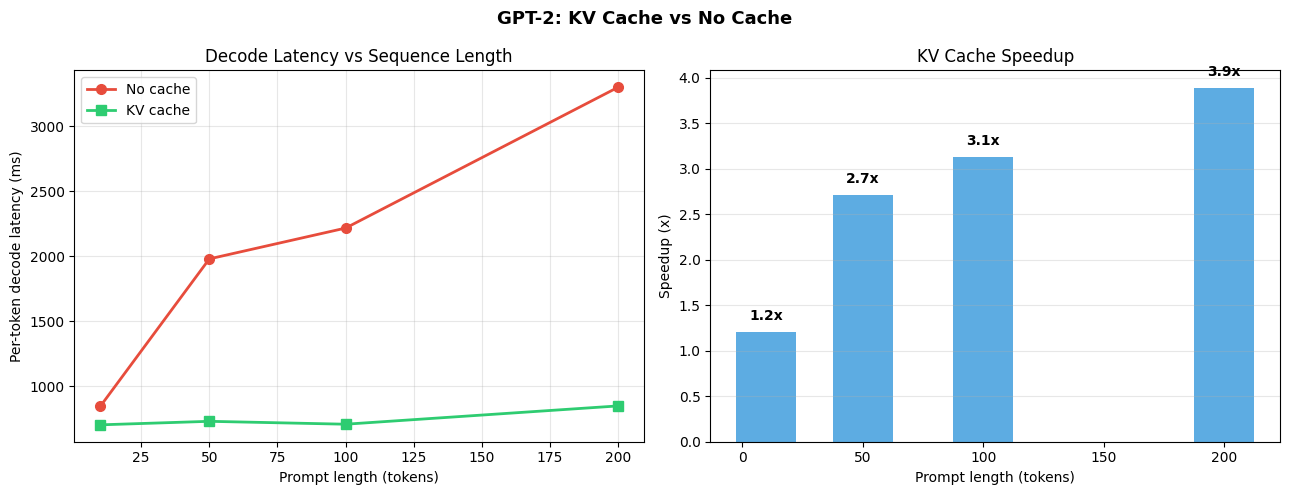


Max speedup measured: 3.9x at seq_len=200


In [7]:
# Plot the speedup curve
seq_lens    = [r[0] for r in results]
no_cache_ms = [r[1] for r in results]
cached_ms   = [r[2] for r in results]
speedups    = [r[3] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-token latency
ax = axes[0]
ax.plot(seq_lens, no_cache_ms, "o-", color="#e74c3c", linewidth=2, markersize=7, label="No cache")
ax.plot(seq_lens, cached_ms,   "s-", color="#2ecc71", linewidth=2, markersize=7, label="KV cache")
ax.set_xlabel("Prompt length (tokens)")
ax.set_ylabel("Per-token decode latency (ms)")
ax.set_title("Decode Latency vs Sequence Length")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: speedup
ax = axes[1]
bars = ax.bar(seq_lens, speedups, color="#3498db", width=25, alpha=0.8)
ax.set_xlabel("Prompt length (tokens)")
ax.set_ylabel("Speedup (x)")
ax.set_title("KV Cache Speedup")
ax.grid(True, alpha=0.3, axis="y")
for bar, s in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{s:.1f}x",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("GPT-2: KV Cache vs No Cache", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nMax speedup measured: {max(speedups):.1f}x at seq_len={seq_lens[speedups.index(max(speedups))]}")

## Memory Cost

KV cache is not free. It trades compute for memory.

**The formula:**

```
kv_cache_bytes = 2 × n_layers × n_heads × head_dim × seq_len × bytes_per_element
```

Where:
- `2` = K and V (not Q — Q isn't cached)
- `n_layers` = transformer depth (12 for GPT-2, 32 for Llama 3 8B, 96 for GPT-3 175B)
- `n_heads × head_dim = n_embd` (the embedding dimension)
- `seq_len` = total context length being generated
- `bytes_per_element` = 4 for float32, 2 for float16/bfloat16

Simplified: `2 × n_layers × n_embd × seq_len × bytes_per_element`

**This scales with batch size too.** Serving 100 concurrent users at 4K context each = 100× the memory.
This is exactly the problem vLLM's PagedAttention solves: manage the KV cache like a virtual memory system,
so you don't have to pre-allocate max_seq_len for every request.

In [8]:
def kv_cache_bytes(n_layers, n_embd, seq_len, dtype_bytes=2):
    """KV cache memory in bytes for a single sequence."""
    return 2 * n_layers * n_embd * seq_len * dtype_bytes

# Model specs: (name, n_layers, n_embd)
MODELS = [
    ("GPT-2 124M",      12,  768),
    ("GPT-2 1.5B",      48, 1600),
    ("Llama 3 8B",      32, 4096),
    ("Llama 3 70B",     80, 8192),
    ("GPT-3 175B",      96, 12288),
]

SEQ_LENGTHS = [512, 2048, 8192, 32768, 131072]

print("KV Cache Memory (float16, single request) in MB")
print("-" * 90)
header = f"{'Model':<20s}" + "".join(f"{s:>12,}" for s in SEQ_LENGTHS)
print(header + "  <- seq_len")
print("-" * 90)

for name, n_layers, n_embd in MODELS:
    row = f"{name:<20s}"
    for seq_len in SEQ_LENGTHS:
        mb = kv_cache_bytes(n_layers, n_embd, seq_len, dtype_bytes=2) / (1024**2)
        row += f"{mb:>12.1f}"
    print(row)

print("-" * 90)
print("Units: MB")
print()

# Show GPT-2's actual current cache usage
prompt_ids = encode("The deployment failed because the configuration was invalid")
_, kv = prefill(prompt_ids)
print(f"GPT-2 actual cache after {kv.seq_len()} tokens: {kv.memory_bytes()/1024:.1f} KB")
print(f"Formula prediction: {kv_cache_bytes(N_LAYER, N_EMBD, kv.seq_len(), 4)/1024:.1f} KB (float32)")
print()
print("Scale: at 32K context, Llama 3 8B needs ~16 GB *just for the KV cache* — per request.")
print("With 10 concurrent requests: 160 GB. Most A100 GPUs have 80 GB total.")
print("This is why KV cache management is the #1 GPU memory challenge in production inference.")

KV Cache Memory (float16, single request) in MB
------------------------------------------------------------------------------------------
Model                        512       2,048       8,192      32,768     131,072  <- seq_len
------------------------------------------------------------------------------------------
GPT-2 124M                  18.0        72.0       288.0      1152.0      4608.0
GPT-2 1.5B                 150.0       600.0      2400.0      9600.0     38400.0
Llama 3 8B                 256.0      1024.0      4096.0     16384.0     65536.0
Llama 3 70B               1280.0      5120.0     20480.0     81920.0    327680.0
GPT-3 175B                2304.0      9216.0     36864.0    147456.0    589824.0
------------------------------------------------------------------------------------------
Units: MB

GPT-2 actual cache after 8 tokens: 1104.0 KB
Formula prediction: 576.0 KB (float32)

Scale: at 32K context, Llama 3 8B needs ~16 GB *just for the KV cache* — per request.

## The Tradeoff: Compute vs Memory

KV caching is the canonical **time-space tradeoff** in ML inference.

```
Without KV cache:
  Compute: O(n²) — re-runs attention over full sequence each step
  Memory:  O(n)  — just the activations for the current forward pass

With KV cache:
  Compute: O(n)  — one new token's projections per step
  Memory:  O(n)  — growing cache (but the constant is 2 × n_layers × n_embd)
```

The memory cost isn't free — it's why **GPU memory capacity** (not compute) is often the binding constraint for serving throughput.

This tension drove three major production systems:

| System | Problem solved | Mechanism |
|---|---|---|
| **vLLM / PagedAttention** | KV cache pre-allocation wastes memory | Paginate KV cache like OS virtual memory — allocate on demand, share between requests with common prefixes |
| **Prefix caching** | Repeated system prompts re-fill cache from scratch | Hash prompt prefixes, reuse KV cache across requests with the same prefix |
| **KV quantization** (e.g., FP8 KV cache in TensorRT-LLM) | Cache grows too large for long contexts | Quantize K and V to 8-bit, halving cache memory at minor accuracy cost |

Understanding KV cache = understanding why all three of those systems exist.

**Infra analogy:** KV cache is RAM. Without it, every query hits disk (recomputes from weights). With it, hot data stays in RAM. The bottleneck shifts from CPU to RAM capacity — which is exactly the memory bandwidth problem you see in vLLM, TGI, and every production serving framework.

## Try These Experiments

**1. Extend the benchmark to longer sequences.**  
Add `300` and `500` to `TEST_LENGTHS` in the benchmark cell. Does the speedup keep growing linearly? What does the cached latency do as the sequence grows? (Hint: it shouldn't stay perfectly flat — why?)

**2. Measure cache memory growth.**  
After each decode step, call `kv.memory_bytes()` and plot it against step number. Verify the slope matches the formula `2 × n_layers × n_embd × bytes_per_element`.

**3. Inspect what's in the cache.**  
After prefill, grab `kv.get(0)` (layer 0's K). Compute the cosine similarity between adjacent rows (position i vs position i+1). Do tokens that are semantically similar end up with similar K vectors? What does this tell you about how attention routing works?

## Key Takeaways

- **Without KV cache**, autoregressive generation is O(n²): every decode step re-runs attention over the full sequence. Per-token latency grows linearly with context length.
- **K and V for past tokens are constant** — they depend only on the tokens that were already generated. Caching them is mathematically lossless.
- **The KV cache is simple**: a per-layer store of K/V matrices. Each decode step appends one row. The query (Q) always attends over the full cached K/V.
- **Memory formula**: `2 × n_layers × n_embd × seq_len × bytes_per_element`. For a 70B model at 32K context in float16: ~160 GB per request — more than a single H100.
- **The tradeoff** — compute for memory — is the root cause behind PagedAttention (vLLM), prefix caching, and KV quantization. Every major inference framework is, in part, a KV cache management system.

## References

- *Inference Engineering* Ch 5.3 (pp. 136–141) — Philip Kiely, Baseten Books 2026
- [Efficient Memory Management for Large Language Model Serving with PagedAttention](https://arxiv.org/abs/2309.06180) — Kwon et al., SOSP 2023
- [FlashAttention-2](https://arxiv.org/abs/2307.08691) — Dao 2023 (reduces attention compute, complements KV cache)
- GPT-2 architecture reference: `config.json` in `gpt2_weights/`